Fundamentals of Deep Learning Models

# Lab 06-2: ResNet for ImageNet Challenge (ILSVRC)
## Exercise: Image classification with ResNet-50

This exercise implements the **ResNet-50** architecture (Section 6.5) using Keras Model Subclassing and trains it on the CIFAR-10 dataset as a practical substitute for ImageNet.

ResNet-50 is built from **bottleneck residual blocks** (Figure 6.9(c), (d)), each consisting of 1×1 → 3×3 → 1×1 convolutions with a skip connection (Eq. 6.2). Two block types are used:
- **Identity block**: the skip connection passes the input unchanged (Figure 6.9(c))
- **Projection block**: a 1×1 convolution on the shortcut path adjusts channel dimensionality and/or spatial resolution (Figure 6.9(d))

The overall architecture follows Table 6.3: an initial 7×7 convolution and max pooling, followed by four stages of residual blocks (3, 4, 6, 3 blocks), global average pooling, and a fully connected softmax classifier.

**Key design features from the text:**
- **Residual learning** with skip connections to address the degradation problem (Section 6.5, Eq. 6.2)
- **Batch Normalization** after every convolution (Section 6.5)
- **He initialization** for all convolutional and dense layers with ReLU (Section 4.4)

**Note:** The original ResNet paper used SGD with momentum and a step-decay learning rate schedule. This exercise uses Adam for convenience.

### Load libraries

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('TensorFlow Datasets version:', tfds.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
TensorFlow Datasets version: 4.9.9
Matplotlib version: 3.10.0
Num GPUs Available:  1


### Prepare datasets

This lab uses the **CIFAR-10** dataset (50,000 training + 10,000 test images, 32×32×3 pixels, 10 classes). An option to load **Imagenette** (a 10-class subset of ImageNet) is also provided.

The training set is split 80/20 into training and validation subsets.

In [ ]:
dataset = 'cifar10'

if dataset == 'cifar10':
    # CIFAR-10: 50,000 training + 10,000 test images, 32x32x3, 10 classes
    (ds_train, ds_test, ds_val), ds_info = tfds.load(
        'cifar10', split=['train[:80%]', 'test', 'train[80%:]'],
        batch_size=None, shuffle_files=True, as_supervised=True,
        with_info=True)
elif dataset == 'imagenette':
    # Imagenette: 10-class subset of ImageNet (320px version)
    (ds_train, ds_test, ds_val), ds_info = tfds.load(
        'imagenette/320px-v2', split=['train', 'validation[:50%]', 'validation[50%:]'],
        batch_size=None, shuffle_files=True, as_supervised=True,
        with_info=True)
else:
    print('Dataset Error')

print(ds_info.features)
print(ds_info.splits)
print(ds_info.splits['train'].num_examples)

In [3]:
n_channels = ds_info.features['image'].shape[-1]

if dataset == 'imagenette':
    classes = ['tench', 'English springer', 'cassette player', 'chain saw',
               'church', 'French horn', 'garbage truck', 'gas pump',
               'golf ball', 'parachute']
else:
    classes = ds_info.features['label'].names
n_classes = ds_info.features['label'].num_classes

n_train = len(ds_train)
n_test = len(ds_test)
n_val = len(ds_val)

print(n_train, n_test, n_val)

40000 10000 10000


### Show a sample image

Image dimension: (32, 32, 3) , label: 8


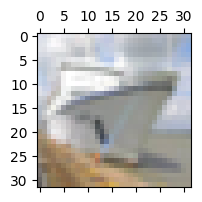

The picture is ship


In [4]:
idx = np.random.randint(n_train - 1)

for element in ds_train.skip(idx).take(1):
    image, label = element

print('Image dimension:', image.shape, ', label:', label.numpy())

dimage = tf.reshape(image, image.shape)
plt.figure(figsize=(2, 2))
plt.matshow(dimage, 0)
plt.show()
print('The picture is', classes[label])

### Building input data pipelines

Images are normalized to $[0, 1]$ and resized to 224×224 to match the ResNet-50 input specification (Table 6.3). Labels are one-hot encoded for the softmax output layer.

In [5]:
def tfds_4_NET(image, label):
    # Normalize pixel values to [0, 1] and resize to 224x224 (ResNet input size)
    image = tf.image.resize((image / 255), [224, 224], method='bilinear')
    # One-hot encode labels for categorical cross-entropy loss
    label = tf.one_hot(label, n_classes)

    return image, label

In [6]:
n_batch = 64

# Build training pipeline: map, shuffle, batch
dataset = ds_train.map(tfds_4_NET, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=256).batch(batch_size=n_batch)

# Build validation pipeline
valiset = ds_val.map(tfds_4_NET, num_parallel_calls=tf.data.AUTOTUNE)
valiset = valiset.shuffle(buffer_size=256).batch(batch_size=n_batch)

# Build test pipeline
testset = ds_test.map(tfds_4_NET, num_parallel_calls=tf.data.AUTOTUNE)
testset = testset.shuffle(buffer_size=256).batch(batch_size=n_batch)

## Build the model for ResNet-50 with Keras Model Subclassing

The ResNet-50 architecture is implemented using two custom layer classes corresponding to the residual block variants described in Section 6.5 and Figure 6.9:
- `IdenBlock`: bottleneck residual block with **identity shortcut** (Figure 6.9(c))
- `ProjBlock`: bottleneck residual block with **projection shortcut** (Figure 6.9(d))

Each bottleneck block computes:

$$\mathbf{y} = \text{ReLU}(\mathbf{x} + F(\mathbf{x})) \quad \text{(Eq. 6.2)}$$

where $F(\mathbf{x})$ is the 1×1 → 3×3 → 1×1 convolution path (Section 6.5).

### Define primitive blocks: identity block and projection block

- **Identity block** (Figure 6.9(c)): input channels match output channels; the shortcut is a direct identity connection.
- **Projection block** (Figure 6.9(d)): a 1×1 convolution with stride $s$ on the shortcut path adjusts channel dimensionality and spatial resolution.

In [ ]:
class IdenBlock(keras.layers.Layer):
    """Bottleneck residual block with identity shortcut (Figure 6.9(c))."""

    def __init__(self, filters, **kwargs):
        super(IdenBlock, self).__init__(**kwargs)
        flt1, flt2, flt3 = filters

        ### START CODE HERE ###

        # 1x1 Conv: reduce channels to flt1 (Section 6.5, bottleneck compression)
        self.conv1 = keras.layers.Conv2D( ... )
        # 3x3 Conv: spatial processing at reduced channel dimension
        self.conv2 = keras.layers.Conv2D( ... )
        # 1x1 Conv: restore channels to flt3 (Section 6.5, bottleneck expansion)
        self.conv3 = keras.layers.Conv2D( ... )

        # BatchNorm after each convolution (Section 6.5)
        self.bn1 = keras.layers.BatchNormalization()
        self.bn2 = keras.layers.BatchNormalization()
        self.bn3 = keras.layers.BatchNormalization()

        # ReLU activations
        self.relu1 = keras.layers.Activation( ... )
        self.relu2 = keras.layers.Activation( ... )
        # Post-addition ReLU (Eq. 6.2: y = ReLU(x + F(x)))
        self.relu3 = keras.layers.Activation( ... )

        # Element-wise addition for skip connection (Eq. 6.2)
        self.add3 = keras.layers.Add()

        ### END CODE HERE ###

    def call(self, x):

        ### START CODE HERE ###

        # Save input for identity shortcut (Eq. 6.2: x)
        x_shortcut = None
        # Residual path: 1x1 -> BN -> ReLU -> 3x3 -> BN -> ReLU -> 1x1 -> BN
        x = None
        x = None
        x = None
        # Add shortcut and apply ReLU (Eq. 6.2: y = ReLU(x + F(x)))
        x = None
        x = None

        ### END CODE HERE ###

        return x


class ProjBlock(keras.layers.Layer):
    """Bottleneck residual block with projection shortcut (Figure 6.9(d))."""

    def __init__(self, filters, st, **kwargs):
        super(ProjBlock, self).__init__(**kwargs)
        flt1, flt2, flt3 = filters

        ### START CODE HERE ###

        # Projection shortcut: 1x1 Conv with stride st (Figure 6.9(d))
        self.conv0 = keras.layers.Conv2D( ... )
        # 1x1 Conv: reduce channels, with stride st for downsampling (Section 6.5)
        self.conv1 = keras.layers.Conv2D( ... )
        # 3x3 Conv: spatial processing at reduced dimension
        self.conv2 = keras.layers.Conv2D( ... )
        # 1x1 Conv: restore channels to flt3
        self.conv3 = keras.layers.Conv2D( ... )

        # BatchNorm for shortcut and residual paths
        self.bn0 = keras.layers.BatchNormalization()
        self.bn1 = keras.layers.BatchNormalization()
        self.bn2 = keras.layers.BatchNormalization()
        self.bn3 = keras.layers.BatchNormalization()

        self.relu1 = keras.layers.Activation( ... )
        self.relu2 = keras.layers.Activation( ... )

        # Post-addition ReLU (Eq. 6.2)
        self.relu3 = keras.layers.Activation( ... )

        # Element-wise addition (Eq. 6.2)
        self.add3 = keras.layers.Add()

        ### END CODE HERE ###

    def call(self, x):

        ### START CODE HERE ###

        # Projection shortcut: 1x1 Conv + BN to match dimensions (Figure 6.9(d))
        x_shortcut = None
        # Residual path: 1x1 -> BN -> ReLU -> 3x3 -> BN -> ReLU -> 1x1 -> BN
        x = None
        x = None
        x = None
        # Add projected shortcut and apply ReLU (Eq. 6.2)
        x = None
        x = None

        ### END CODE HERE ###

        return x

### Build the entire ResNet-50 model

The block configuration follows Table 6.3:

| Stage | Block type | Repetitions | Channels | Stride |
|-------|-----------|-------------|----------|--------|
| Conv1 | 7×7 Conv + MaxPool | 1 | 64 | 2 |
| Conv2 | Bottleneck | 3 (1 Proj + 2 Iden) | 256 | 1 |
| Conv3 | Bottleneck | 4 (1 Proj + 3 Iden) | 512 | 2 |
| Conv4 | Bottleneck | 6 (1 Proj + 5 Iden) | 1024 | 2 |
| Conv5 | Bottleneck | 3 (1 Proj + 2 Iden) | 2048 | 2 |

In [ ]:
class ResNet50(keras.Model):

    def __init__(self, num_classes=10, **kwargs):
        super(ResNet50, self).__init__()

        ### START CODE HERE ###

        # Stage 1: 7x7 Conv, stride 2, 64 channels -> BN -> ReLU -> MaxPool (Table 6.3)
        self.cnv1_cv = keras.layers.Conv2D(...)
        self.cnv1_bn = keras.layers.BatchNormalization()
        self.cnv1_ac = keras.layers.Activation(...)
        self.cnv1_pl = keras.layers.MaxPool2D(...)

        # Stage 2: 3 bottleneck blocks, 256 channels (Table 6.3)
        self.cnv2_b1 = None         # 1st Residual (projection)
        self.cnv2_b2 = None         # 2nd Residual (identity)
        self.cnv2_b3 = None         # 3rd Residual (identity)

        # Stage 3: 4 bottleneck blocks, 512 channels, stride 2 downsample (Table 6.3)
        self.cnv3_b1 = None         # 4th Residual (projection)
        self.cnv3_b2 = None         # 5th Residual
        self.cnv3_b3 = None         # 6th Residual
        self.cnv3_b4 = None         # 7th Residual

        # Stage 4: 6 bottleneck blocks, 1024 channels, stride 2 downsample (Table 6.3)
        self.cnv4_b1 = None         # 8th Residual (projection)
        self.cnv4_b2 = None         # 9th Residual
        self.cnv4_b3 = None         # 10th Residual
        self.cnv4_b4 = None         # 11th Residual
        self.cnv4_b5 = None         # 12th Residual
        self.cnv4_b6 = None         # 13th Residual

        # Stage 5: 3 bottleneck blocks, 2048 channels, stride 2 downsample (Table 6.3)
        self.cnv5_b1 = None         # 14th Residual (projection)
        self.cnv5_b2 = None         # 15th Residual
        self.cnv5_b3 = None         # 16th Residual
        # Average pooling (see note above on deviation from Table 6.3)
        self.cnv5_p1 = keras.layers....

        # Output: Flatten -> Dense softmax (Table 6.3)
        self.lyr6_fc = keras.layers.Dense(...)

        ### END CODE HERE ###

    def call(self, inputs):
        x = self.cnv1_pl(self.cnv1_ac(self.cnv1_bn(self.cnv1_cv(inputs))))
        x = self.cnv2_b3(self.cnv2_b2(self.cnv2_b1(x)))
        x = self.cnv3_b4(self.cnv3_b3(self.cnv3_b2(self.cnv3_b1(x))))
        x = self.cnv4_b6(self.cnv4_b5(self.cnv4_b4(self.cnv4_b3(self.cnv4_b2(self.cnv4_b1(x))))))
        x = self.cnv5_p1(self.cnv5_b3(self.cnv5_b2(self.cnv5_b1(x))))
        x = self.lyr6_fc(x)
        return x

### Training the model

The model is compiled with **categorical cross-entropy** loss. The original ResNet paper used SGD with momentum and a step-decay learning rate schedule (Section 6.5); **Adam** is used here for convenience.

In [9]:
ResNet = ResNet50()
# Build the model by running a single forward pass
ResNet.call(keras.layers.Input(shape=(224, 224, n_channels)))
ResNet.summary(show_trainable=True)

# Compile with Adam optimizer
opt = keras.optimizers.Adam(learning_rate=1e-3)
ResNet.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['acc'])

Model: "res_net50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d (Conv2D)             │ (None, 112, 112, 64)  │      9,472 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 112, 112, 64)  │        256 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ activation (Activation)     │ (None, 112, 112, 64)  │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d               │ (None, 56, 56, 64)    │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ proj_block (ProjBlock)      │ (None, 56, 56, 256)   │     76,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block (IdenBlock)      │ (None, 56, 56, 256)   │     71,552 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_1 (IdenBlock)    │ (None, 56, 56, 256)   │     71,552 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ proj_block_1 (ProjBlock)    │ (None, 28, 28, 512)   │    383,232 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_2 (IdenBlock)    │ (None, 28, 28, 512)   │    282,368 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_3 (IdenBlock)    │ (None, 28, 28, 512)   │    282,368 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_4 (IdenBlock)    │ (None, 28, 28, 512)   │    282,368 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ proj_block_2 (ProjBlock)    │ (None, 14, 14, 1024)  │  1,520,128 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_5 (IdenBlock)    │ (None, 14, 14, 1024)  │  1,121,792 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_6 (IdenBlock)    │ (None, 14, 14, 1024)  │  1,121,792 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_7 (IdenBlock)    │ (None, 14, 14, 1024)  │  1,121,792 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_8 (IdenBlock)    │ (None, 14, 14, 1024)  │  1,121,792 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_9 (IdenBlock)    │ (None, 14, 14, 1024)  │  1,121,792 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ proj_block_3 (ProjBlock)    │ (None, 7, 7, 2048)    │  6,054,912 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_10 (IdenBlock)   │ (None, 7, 7, 2048)    │  4,471,808 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ iden_block_11 (IdenBlock)   │ (None, 7, 7, 2048)    │  4,471,808 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     20,490 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [10]:
n_epochs = 5

results = ResNet.fit(dataset, epochs=n_epochs, batch_size=n_batch,
                     validation_data=valiset, validation_batch_size=n_batch,
                     verbose=1)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 437s 602ms/step - acc: 0.3090 - loss: 16.8698 - val_acc: 0.4178 - val_loss: 1.5460
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 373s 597ms/step - acc: 0.4605 - loss: 1.4705 - val_acc: 0.4826 - val_loss: 1.4452
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 382s 598ms/step - acc: 0.5404 - loss: 1.2655 - val_acc: 0.5658 - val_loss: 1.2162
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 375s 599ms/step - acc: 0.6125 - loss: 1.0868 - val_acc: 0.6184 - val_loss: 1.0726
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 374s 599ms/step - acc: 0.6658 - loss: 0.9490 - val_acc: 0.6549 - val_loss: 0.9690


In [11]:
# Uncomment to save the trained model
# ResNet.save('ResNet50.keras')

### Plot convergence graph

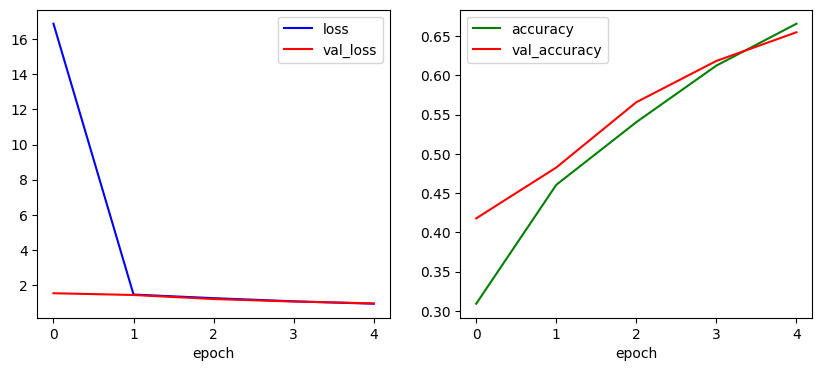

In [12]:
# Plot training/validation loss and accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'], 'b-', label='loss')
plt.plot(results.history['val_loss'], 'r-', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results.history['acc'], 'g-', label='accuracy')
plt.plot(results.history['val_acc'], 'r-', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()

plt.show()

### Evaluate model performance

In [13]:
# Evaluate on the test set
ResNet.evaluate(testset)

157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - acc: 0.6566 - loss: 0.9697


[0.9697063565254211, 0.6565999984741211]

### Test model with a random sample

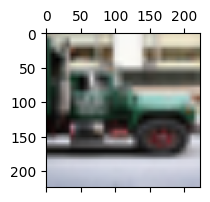

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
My prediction is truck
Actual image is  truck


In [14]:
idx = np.random.randint(n_test - 1)

for element in ds_test.skip(idx).take(1):
    img, lbl = element
    X_test, y_test = tfds_4_NET(img, lbl)

# Add batch dimension for prediction
X_test = tf.expand_dims(X_test, axis=0)

# Display the test image
dimage = np.array(X_test[0])
plt.figure(figsize=(2, 2))
plt.matshow(dimage, 0)
plt.show()

# Predict and compare
outt_4 = ResNet.predict(X_test)
p_pred = np.argmax(outt_4, axis=-1)

print('My prediction is ' + classes[p_pred[0]])
print('Actual image is  ' + classes[tf.argmax(y_test, -1)])

(c) 2026 S. W. Lee